# 01 · EDA Dataset Construction Safety

Capstone Project Module 4. Notebook ini menopang komponen **Pipeline Data
Processing**, dan tugasnya satu, memastikan datanya layak sebelum satu baris pun
kode training ditulis.

Dokumen SOAL menulis pipeline harus memuat *"semua proses yang dibutuhkan untuk
mengolah data untuk selanjutnya masuk ke model object detection"*. Notebook ini
menjalankan lima pemeriksaan, dan tiap pemeriksaan ditutup kesimpulan yang
menentukan keputusan berikutnya.

| # | Pemeriksaan | Yang dicari |
|---|---|---|
| 1 | Integritas label | pasangan gambar dan label, nilai koordinat, kotak cacat |
| 2 | Kebersihan split | data leakage dan berkas duplikat |
| 3 | Distribusi kelas | kelas yang terlalu langka untuk dipercaya |
| 4 | Ukuran objek | apakah objeknya terlalu kecil untuk resolusi bawaan |
| 5 | Kualitas gambar | pencahayaan, kontras, dan ukuran ekstrem |

Notebook ini **tidak melatih apa pun**. Keluarannya angka dan keputusan.

Cara menjalankan, unggah `construction safety.v1i.yolov12.zip` ke Google Drive,
lalu jalankan sel dari atas ke bawah. Tidak butuh GPU.

In [1]:
!pip install -q pyyaml pillow numpy matplotlib


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os, glob, re, json, zipfile, hashlib, collections
import numpy as np
import matplotlib.pyplot as plt
import yaml
from PIL import Image

# ---------------------------------------------------------------- lokasi data
# Tiga cara, notebook memakai yang pertama yang ketemu.
KANDIDAT_ZIP = [
    "/content/drive/MyDrive/capstone4/construction safety.v1i.yolov12.zip",
    "construction safety.v1i.yolov12.zip",
    "../../pilihan dataset dan aturan/construction safety.v1i.yolov12.zip",
    "../pilihan dataset dan aturan/construction safety.v1i.yolov12.zip",
]
ROOT = "dataset"

if not os.path.isdir(ROOT):
    sumber = next((p for p in KANDIDAT_ZIP if os.path.exists(p)), None)
    if sumber is None:
        try:
            from google.colab import drive
            drive.mount("/content/drive")
            sumber = next((p for p in KANDIDAT_ZIP if os.path.exists(p)), None)
        except ImportError:
            pass
    if sumber is None:
        raise FileNotFoundError(
            "Zip dataset tidak ditemukan. Unggah ke Drive di "
            "MyDrive/capstone4/ atau sesuaikan KANDIDAT_ZIP."
        )
    print("mengekstrak dari", sumber)
    with zipfile.ZipFile(sumber) as z:
        z.extractall(ROOT)

cfg = yaml.safe_load(open(glob.glob(f"{ROOT}/*.yaml")[0]))
NAMES = cfg["names"] if isinstance(cfg["names"], list) else list(cfg["names"].values())
SPLITS = ["train", "valid", "test"]

print("ROOT  :", ROOT)
print("kelas :", NAMES)
print()
print("PENTING, indeks kelas ditentukan urutan di data.yaml, bukan kepentingannya.")
for i, n in enumerate(NAMES):
    print(f"   {i} = {n}")

ROOT  : dataset
kelas : ['helmet', 'no-helmet', 'no-vest', 'person', 'vest']

PENTING, indeks kelas ditentukan urutan di data.yaml, bukan kepentingannya.
   0 = helmet
   1 = no-helmet
   2 = no-vest
   3 = person
   4 = vest


**Catatan pertama yang sudah bisa diambil.** `person` berada di indeks 3, bukan 0.
Kode yang mengasumsikan kelas terpenting ada di indeks 0 akan salah total tanpa
memunculkan error apa pun. Seluruh notebook ini membaca nama kelas dari
`data.yaml`, tidak pernah menuliskan indeks langsung.

---

## Pemeriksaan 1 · Integritas label

Yang diperiksa ada enam. Pasangan gambar dan label, jumlah kolom tiap baris,
nilai koordinat harus berada di 0 sampai 1, `class_id` harus lebih kecil dari
jumlah kelas, kotak tidak boleh berukuran nol, dan kotak tidak boleh melewati
tepi gambar.

Label yang cacat tidak membuat training gagal. Ia membuat training **diam-diam**
mempelajari kotak yang salah, dan itu jauh lebih sulit dilacak.

In [3]:
def baca_label(path):
    """Baca satu berkas label YOLO. Mengembalikan daftar (class_id, cx, cy, w, h)."""
    out = []
    for baris in open(path):
        p = baris.split()
        if p:
            out.append(p)
    return out


masalah = []
kosong = 0
total_baris = 0

for split in SPLITS:
    gambar = glob.glob(f"{ROOT}/{split}/images/*")
    label = glob.glob(f"{ROOT}/{split}/labels/*.txt")
    sg = {os.path.splitext(os.path.basename(p))[0] for p in gambar}
    sl = {os.path.splitext(os.path.basename(p))[0] for p in label}
    print(f"{split:6} {len(gambar):5d} gambar  {len(label):5d} label   "
          f"gambar tanpa label {len(sg - sl):3d}   label tanpa gambar {len(sl - sg):3d}")

    for lp in label:
        baris = baca_label(lp)
        if not baris:
            kosong += 1
            continue
        for i, p in enumerate(baris, 1):
            total_baris += 1
            nama = os.path.basename(lp)
            if len(p) != 5:
                masalah.append((nama, i, "jumlah kolom bukan 5")); continue
            try:
                ci = int(p[0]); cx, cy, w, h = map(float, p[1:])
            except ValueError:
                masalah.append((nama, i, "nilai bukan angka")); continue
            if not 0 <= ci < len(NAMES):
                masalah.append((nama, i, f"class_id {ci} di luar rentang"))
            if any(not 0 <= v <= 1 for v in (cx, cy, w, h)):
                masalah.append((nama, i, "koordinat di luar 0 sampai 1"))
            if w <= 0 or h <= 0:
                masalah.append((nama, i, "lebar atau tinggi nol"))
            if (cx - w/2 < -1e-6 or cx + w/2 > 1 + 1e-6
                    or cy - h/2 < -1e-6 or cy + h/2 > 1 + 1e-6):
                masalah.append((nama, i, "kotak melewati tepi gambar"))

print()
print(f"baris label diperiksa : {total_baris}")
print(f"berkas label kosong   : {kosong}")
print(f"baris bermasalah      : {len(masalah)}")
for m in masalah[:10]:
    print("   ", m)

train    997 gambar    997 label   gambar tanpa label   0   label tanpa gambar   0


valid    119 gambar    119 label   gambar tanpa label   0   label tanpa gambar   0
test      90 gambar     90 label   gambar tanpa label   0   label tanpa gambar   0

baris label diperiksa : 7724
berkas label kosong   : 0
baris bermasalah      : 0


In [4]:
# Dua cacat halus yang tidak melanggar format tapi tetap layak diketahui.
sangat_kecil = collections.Counter()
duplikat = 0

for split in SPLITS:
    for lp in glob.glob(f"{ROOT}/{split}/labels/*.txt"):
        baris = [b.strip() for b in open(lp) if b.strip()]
        duplikat += len(baris) - len(set(baris))
        for b in baris:
            p = b.split()
            if len(p) == 5 and (float(p[3]) < 0.01 or float(p[4]) < 0.01):
                sangat_kecil[NAMES[int(p[0])]] += 1

print("kotak dengan sisi ternormalisasi di bawah 0,01 :", dict(sangat_kecil) or "tidak ada")
print("kotak duplikat persis dalam satu gambar        :", duplikat)

kotak dengan sisi ternormalisasi di bawah 0,01 : {'person': 2, 'helmet': 1, 'no-vest': 1}
kotak duplikat persis dalam satu gambar        : 0


### Kesimpulan pemeriksaan 1

Dataset ini **bersih secara format**. 7.724 baris label, nol baris bermasalah,
nol berkas label kosong, nol kotak duplikat.

Ada empat kotak dengan sisi ternormalisasi di bawah 0,01, satu helmet, satu
no-vest, dan dua person. Pada gambar 640 piksel itu setara kurang dari 7 piksel.
Jumlahnya terlalu sedikit untuk mempengaruhi apa pun, jadi dibiarkan.

Membuktikan tidak ada masalah sama bernilainya dengan menemukan masalah. Tanpa
pemeriksaan ini, angka evaluasi nanti tidak punya dasar untuk dipercaya.

---

## Pemeriksaan 2 · Kebersihan split

Ini pemeriksaan paling berbahaya kalau dilewatkan. Kalau gambar yang sama muncul
di train dan test, model tidak mengenali melainkan mengingat, dan seluruh angka
evaluasi menjadi palsu.

Diperiksa dua cara. Pertama lewat id gambar setelah membuang hash Roboflow,
kedua lewat md5 isi berkas yang menangkap duplikat meski namanya berbeda.

In [5]:
def id_asli(path):
    """Buang hash yang ditambahkan Roboflow, sisakan id gambar aslinya."""
    nama = os.path.splitext(os.path.basename(path))[0]
    return re.sub(r"_jpg\.rf\.[0-9a-f]+$", "", nama)


S = {s: {id_asli(p) for p in glob.glob(f"{ROOT}/{s}/images/*")} for s in SPLITS}
for s in SPLITS:
    print(f"{s:6} {len(glob.glob(f'{ROOT}/{s}/images/*')):5d} berkas, "
          f"{len(S[s]):5d} id unik")

print()
print("irisan train dan valid :", len(S["train"] & S["valid"]))
print("irisan train dan test  :", len(S["train"] & S["test"]))
print("irisan valid dan test  :", len(S["valid"] & S["test"]))

h = collections.defaultdict(list)
for p in glob.glob(f"{ROOT}/*/images/*"):
    h[hashlib.md5(open(p, "rb").read()).hexdigest()].append(p)
dup = [v for v in h.values() if len(v) > 1]
lintas = [v for v in dup if len({x.split(os.sep)[-3] for x in v}) > 1]

print()
print(f"berkas dengan md5 identik      : {len(dup)}")
print(f"identik dan LINTAS split       : {len(lintas)}")

train    997 berkas,   997 id unik
valid    119 berkas,   119 id unik
test      90 berkas,    90 id unik

irisan train dan valid : 0
irisan train dan test  : 0
irisan valid dan test  : 0



berkas dengan md5 identik      : 0
identik dan LINTAS split       : 0


### Kesimpulan pemeriksaan 2

**Tidak ada data leakage.** Tidak satu pun id gambar muncul di lebih dari satu
split, dan tidak ada berkas dengan isi identik.

Artinya angka evaluasi di test set nanti layak dipercaya, dan itu bukan asumsi
melainkan hasil pemeriksaan.

---

## Pemeriksaan 3 · Distribusi kelas

Yang dicari kelas yang instance-nya terlalu sedikit, terutama kalau kelas itu
justru yang paling penting bagi kasus yang diselesaikan.

In [6]:
jumlah = {s: collections.Counter() for s in SPLITS}
for split in SPLITS:
    for lp in glob.glob(f"{ROOT}/{split}/labels/*.txt"):
        for p in baca_label(lp):
            if len(p) == 5:
                jumlah[split][NAMES[int(p[0])]] += 1

total = collections.Counter()
for s in SPLITS:
    total.update(jumlah[s])
T = sum(total.values())

print(f"{'kelas':12} {'train':>7} {'valid':>7} {'test':>7} {'total':>8} {'porsi':>7}")
print("-" * 52)
for n in sorted(NAMES, key=lambda x: -total[x]):
    print(f"{n:12} {jumlah['train'][n]:7d} {jumlah['valid'][n]:7d} "
          f"{jumlah['test'][n]:7d} {total[n]:8d} {100*total[n]/T:6.1f}%")
print("-" * 52)
print(f"{'TOTAL':12} {sum(jumlah['train'].values()):7d} "
      f"{sum(jumlah['valid'].values()):7d} {sum(jumlah['test'].values()):7d} {T:8d}")

kelas          train   valid    test    total   porsi
----------------------------------------------------
person          2362     241     214     2817   36.5%
helmet          2116     232     195     2543   32.9%
vest            1073     141     129     1343   17.4%
no-vest          741      90      61      892   11.5%
no-helmet         94      11      24      129    1.7%
----------------------------------------------------
TOTAL           6386     715     623     7724


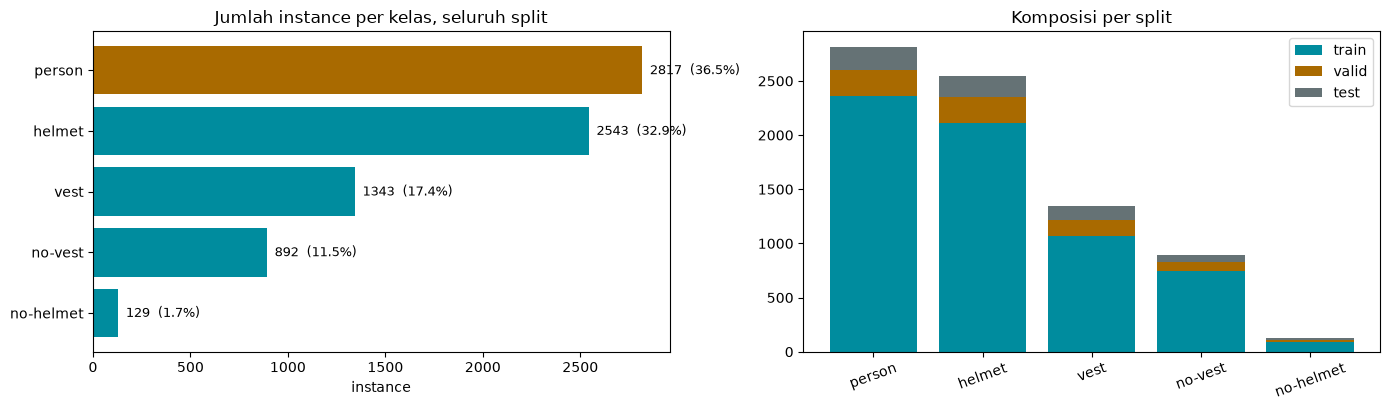

Jumlah instance di validation split, ini yang menentukan apakah AP per
kelas bisa dipercaya:
   person        241
   helmet        232
   vest          141
   no-vest        90
   no-helmet      11  <- terlalu sedikit, AP tidak stabil


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))

urut = sorted(NAMES, key=lambda x: -total[x])
ax[0].barh(urut[::-1], [total[n] for n in urut][::-1],
           color=["#008C9E"] * (len(urut) - 1) + ["#A96A00"])
ax[0].set_title("Jumlah instance per kelas, seluruh split")
ax[0].set_xlabel("instance")
for i, n in enumerate(urut[::-1]):
    ax[0].text(total[n] + 40, i, f"{total[n]}  ({100*total[n]/T:.1f}%)",
               va="center", fontsize=9)

bawah = np.zeros(len(urut))
for s, warna in zip(SPLITS, ["#008C9E", "#A96A00", "#657275"]):
    v = np.array([jumlah[s][n] for n in urut])
    ax[1].bar(urut, v, bottom=bawah, label=s, color=warna)
    bawah += v
ax[1].set_title("Komposisi per split")
ax[1].legend(); ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

print("Jumlah instance di validation split, ini yang menentukan apakah AP per")
print("kelas bisa dipercaya:")
for n in urut:
    v = jumlah["valid"][n]
    tanda = "  <- terlalu sedikit, AP tidak stabil" if v < 30 else ""
    print(f"   {n:12} {v:4d}{tanda}")

### Kesimpulan pemeriksaan 3

Ini temuan terpenting di seluruh notebook.

**Kelas `no-helmet` hanya 1,7 persen dari seluruh anotasi**, 129 kotak dari
7.724, dengan rasio 1 banding 19,7 terhadap `helmet`. Padahal itu justru kelas
yang paling penting bagi kasus keselamatan. Hal yang jarang terjadi memang lebih
jarang difoto.

**Validation split hanya punya 11 instance `no-helmet`.** Satu deteksi benar atau
salah menggeser AP kelas itu sekitar sembilan persen. Angka AP `no-helmet` di
validation praktis tidak bisa dipercaya, dan itu harus dinyatakan terbuka di
laporan, bukan disembunyikan di balik mAP rata-rata.

Tiga keputusan yang mengikuti.

1. Evaluasi akhir dilaporkan di **test set**, yang punya 24 instance, dan recall
   `no-helmet` dilaporkan **terpisah** dari mAP keseluruhan.
2. Penanganan kelas langka dicoba di hari 8 sampai 10, dimulai dari copy-paste
   augmentation karena paling murah dan efeknya terukur.
3. Perbaikan apa pun dinilai lewat eksperimen berpasangan, recall `no-helmet`
   sebelum dan sesudah, pada test set nyata yang sama persis.

---

## Pemeriksaan 4 · Ukuran objek dan pemilihan resolusi

Patokan dari materi, object detection paling andal untuk objek yang menutupi
**2 sampai 60 persen** luas gambar. Di bawah itu objeknya terlalu kecil untuk
diwakili feature map.

Dataset ini diukur terhadap patokan tersebut.

In [8]:
luas = collections.defaultdict(list)
box_per_gambar = []

for lp in glob.glob(f"{ROOT}/train/labels/*.txt"):
    baris = baca_label(lp)
    box_per_gambar.append(len(baris))
    for p in baris:
        if len(p) == 5:
            luas[NAMES[int(p[0])]].append(float(p[3]) * float(p[4]) * 100)

print(f"{'kelas':12} {'n':>6} {'p10':>8} {'median':>8} {'p90':>8} {'di bawah 2%':>12}")
print("-" * 58)
for n in sorted(NAMES, key=lambda x: np.median(luas[x]) if luas[x] else 0):
    a = np.array(luas[n])
    kecil = (a < 2).mean() * 100
    print(f"{n:12} {len(a):6d} {np.percentile(a,10):7.2f}% "
          f"{np.median(a):7.2f}% {np.percentile(a,90):7.2f}% {kecil:11.1f}%")

print()
print(f"objek per gambar, rata-rata {np.mean(box_per_gambar):.2f}, "
      f"median {int(np.median(box_per_gambar))}, maksimum {max(box_per_gambar)}")

kelas             n      p10   median      p90  di bawah 2%
----------------------------------------------------------
no-helmet        94    0.19%    0.62%    1.98%        89.4%
helmet         2116    0.19%    0.89%    4.62%        69.7%
vest           1073    0.83%    4.10%   16.64%        30.6%
no-vest         741    0.83%    4.62%   18.21%        27.0%
person         2362    1.66%   10.18%   35.24%        11.7%

objek per gambar, rata-rata 6.41, median 6, maksimum 39


In [9]:
# Terjemahkan ke piksel setelah letterbox, supaya bisa dibandingkan dengan
# definisi objek small pada metrik COCO, yaitu sisi di bawah 32 piksel.
def sisi_piksel(imgsz):
    hasil = collections.defaultdict(list)
    for lp in glob.glob(f"{ROOT}/train/labels/*.txt"):
        ip = lp.replace(f"{os.sep}labels{os.sep}", f"{os.sep}images{os.sep}")[:-4] + ".jpg"
        if not os.path.exists(ip):
            continue
        W, H = Image.open(ip).size
        r = min(imgsz / W, imgsz / H)          # skala letterbox
        for p in baca_label(lp):
            if len(p) == 5:
                w = float(p[3]) * W * r
                h = float(p[4]) * H * r
                hasil[NAMES[int(p[0])]].append(min(w, h))
    return hasil

px640 = sisi_piksel(640)
px960 = sisi_piksel(960)

print(f"{'kelas':12} {'<32px @640':>12} {'<32px @960':>12} {'perbaikan':>11}")
print("-" * 50)
for n in sorted(NAMES, key=lambda x: -(np.array(px640[x]) < 32).mean()):
    a = (np.array(px640[n]) < 32).mean() * 100
    b = (np.array(px960[n]) < 32).mean() * 100
    print(f"{n:12} {a:11.1f}% {b:11.1f}% {a-b:10.1f} poin")

kelas          <32px @640   <32px @960   perbaikan
--------------------------------------------------
no-helmet           47.9%        17.0%       30.9 poin
helmet              32.6%        14.1%       18.5 poin
no-vest              7.7%         4.9%        2.8 poin
vest                 5.8%         1.2%        4.6 poin
person               5.1%         1.3%        3.8 poin


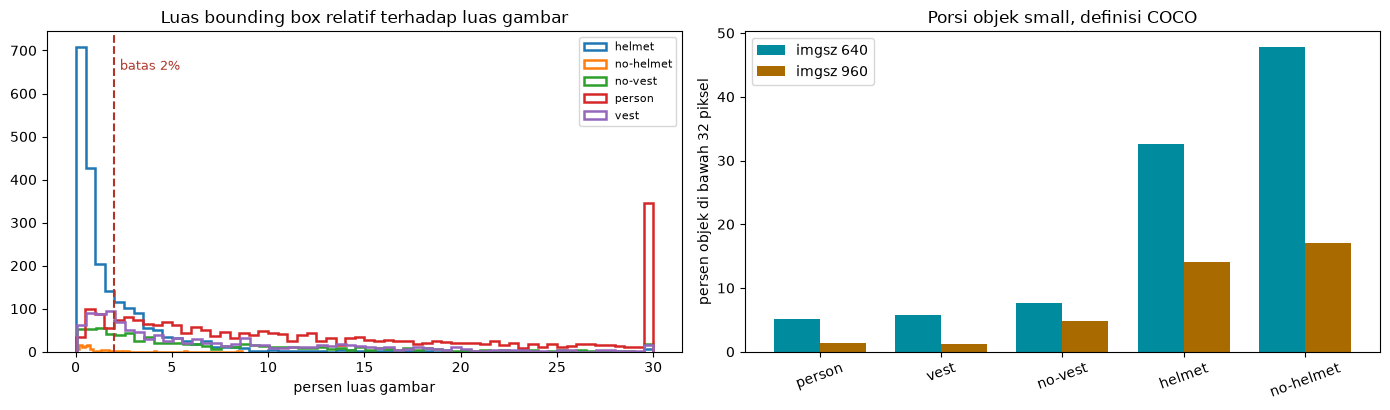

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))

for n in NAMES:
    ax[0].hist(np.clip(luas[n], 0, 30), bins=60, histtype="step", lw=1.8, label=n)
ax[0].axvline(2, color="#AE3527", ls="--", lw=1.5)
ax[0].text(2.3, ax[0].get_ylim()[1]*0.88, "batas 2%", color="#AE3527", fontsize=9)
ax[0].set_title("Luas bounding box relatif terhadap luas gambar")
ax[0].set_xlabel("persen luas gambar"); ax[0].legend(fontsize=8)

urut = sorted(NAMES, key=lambda x: (np.array(px640[x]) < 32).mean())
x = np.arange(len(urut)); w = 0.38
ax[1].bar(x - w/2, [(np.array(px640[n]) < 32).mean()*100 for n in urut], w,
          label="imgsz 640", color="#008C9E")
ax[1].bar(x + w/2, [(np.array(px960[n]) < 32).mean()*100 for n in urut], w,
          label="imgsz 960", color="#A96A00")
ax[1].set_xticks(x); ax[1].set_xticklabels(urut, rotation=20)
ax[1].set_ylabel("persen objek di bawah 32 piksel")
ax[1].set_title("Porsi objek small, definisi COCO")
ax[1].legend()
plt.tight_layout(); plt.show()

### Kesimpulan pemeriksaan 4

**Dua kelas yang menentukan vonis keselamatan justru paling kecil.** 68,7 persen
`helmet` dan 88,4 persen `no-helmet` menutupi kurang dari 2 persen luas gambar,
di bawah batas bawah rentang yang disebut materi.

Diterjemahkan ke piksel, pada `imgsz` 640 sebanyak 32,6 persen `helmet` dan
47,9 persen `no-helmet` berada di bawah 32 piksel, yaitu definisi objek small
pada metrik COCO. Menaikkan `imgsz` ke 960 memotong angka itu menjadi 14,1 dan
17,0 persen.

**Keputusan.** `imgsz` dijadikan variabel eksperimen, bukan ditetapkan sekarang.
Hari 3 memakai 640 sebagai baseline, hari 8 sampai 10 membandingkannya dengan
960. Biaya waktunya naik kira-kira kuadrat rasio sisi, jadi sekitar 2,25 kali.

Ini bukan preferensi gaya. Ada angka yang bisa ditunjuk kalau ditanya kenapa
resolusinya dinaikkan.

Catatan tambahan, rata-rata 6,41 objek per gambar dengan maksimum 39 berarti
gambarnya padat dan pekerja sering berhimpitan. Itu akan menyulitkan asosiasi
atribut ke pekerja di hari 4, dan sudah bisa diantisipasi sekarang.

---

## Pemeriksaan 5 · Kualitas gambar

Kondisi pencahayaan adalah masalah kualitas data yang pertama disebut materi.
Diperiksa lewat statistik histogram, karena memeriksa 1.206 gambar satu per satu
dengan mata tidak mungkin.

In [11]:
stats = []
rusak = []

for p in sorted(glob.glob(f"{ROOT}/*/images/*")):
    try:
        Image.open(p).verify()                       # deteksi berkas rusak
        im = Image.open(p)
        g = np.asarray(im.convert("L"))
        stats.append({"path": p, "mean": g.mean(), "std": g.std(),
                      "w": im.size[0], "h": im.size[1]})
    except Exception as e:
        rusak.append((p, type(e).__name__))

m = np.array([s["mean"] for s in stats])
sd = np.array([s["std"] for s in stats])
gelap = [s for s in stats if s["mean"] < 60]
terang = [s for s in stats if s["mean"] > 200]
datar = [s for s in stats if s["std"] < 30]

print(f"gambar diperiksa : {len(stats)}")
print(f"berkas rusak     : {len(rusak)}")
print()
print(f"mean brightness  p05={np.percentile(m,5):6.1f}  median={np.median(m):6.1f}  p95={np.percentile(m,95):6.1f}")
print(f"standar deviasi  p05={np.percentile(sd,5):6.1f}  median={np.median(sd):6.1f}  p95={np.percentile(sd,95):6.1f}")
print()
print(f"gelap, mean < 60           : {len(gelap):3d}  ({100*len(gelap)/len(stats):.1f}%)")
print(f"terang berlebih, mean > 200: {len(terang):3d}  ({100*len(terang)/len(stats):.1f}%)")
print(f"kontras rendah, std < 30   : {len(datar):3d}  ({100*len(datar)/len(stats):.1f}%)")

gambar diperiksa : 1206
berkas rusak     : 0

mean brightness  p05=  78.5  median= 132.0  p95= 202.9
standar deviasi  p05=  43.4  median=  61.4  p95=  80.3

gelap, mean < 60           :  24  (2.0%)
terang berlebih, mean > 200:  68  (5.6%)
kontras rendah, std < 30   :   3  (0.2%)


rasio aspek   min=0.45  median=1.50  max=3.75
megapiksel    min=0.02  median=0.60  max=30.38
resolusi berbeda : 721


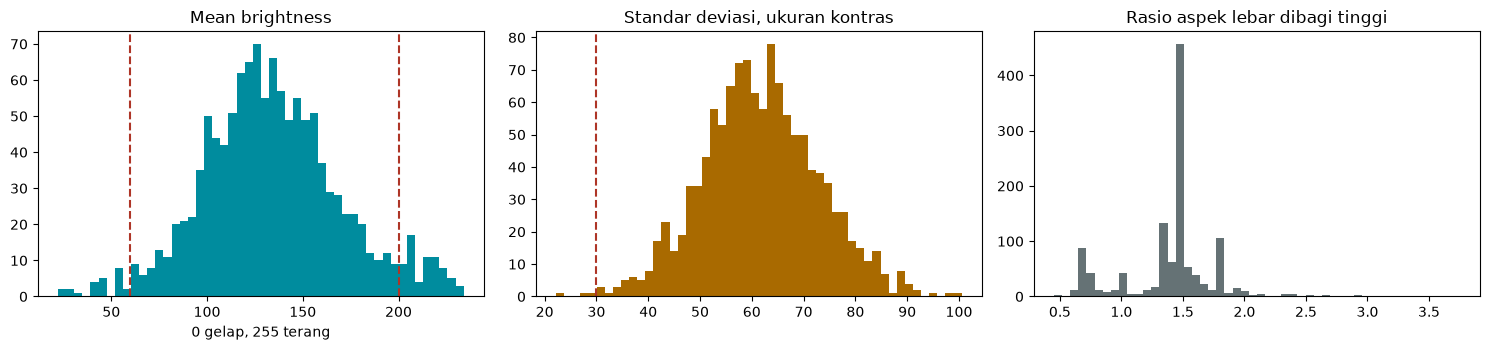

In [12]:
ar = np.array([s["w"] / s["h"] for s in stats])
mp = np.array([s["w"] * s["h"] / 1e6 for s in stats])

print(f"rasio aspek   min={ar.min():.2f}  median={np.median(ar):.2f}  max={ar.max():.2f}")
print(f"megapiksel    min={mp.min():.2f}  median={np.median(mp):.2f}  max={mp.max():.2f}")
print(f"resolusi berbeda : {len({(s['w'], s['h']) for s in stats})}")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].hist(m, bins=50, color="#008C9E")
ax[0].axvline(60, color="#AE3527", ls="--"); ax[0].axvline(200, color="#AE3527", ls="--")
ax[0].set_title("Mean brightness"); ax[0].set_xlabel("0 gelap, 255 terang")
ax[1].hist(sd, bins=50, color="#A96A00")
ax[1].axvline(30, color="#AE3527", ls="--")
ax[1].set_title("Standar deviasi, ukuran kontras")
ax[2].hist(ar, bins=50, color="#657275")
ax[2].set_title("Rasio aspek lebar dibagi tinggi")
plt.tight_layout(); plt.show()

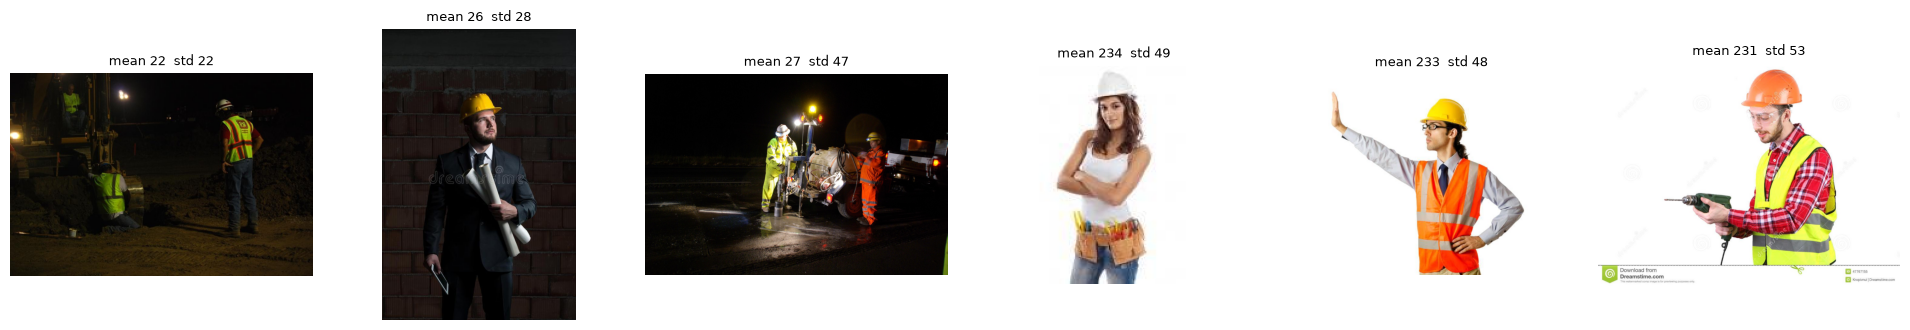

In [13]:
# Lihat sendiri gambar yang paling bermasalah, jangan cuma percaya angkanya.
contoh = sorted(gelap, key=lambda s: s["mean"])[:3] + sorted(terang, key=lambda s: -s["mean"])[:3]
if contoh:
    fig, ax = plt.subplots(1, len(contoh), figsize=(3.2*len(contoh), 3.4))
    for a, s in zip(np.atleast_1d(ax), contoh):
        a.imshow(Image.open(s["path"]).convert("RGB"))
        a.set_title(f"mean {s['mean']:.0f}  std {s['std']:.0f}", fontsize=9)
        a.axis("off")
    plt.tight_layout(); plt.show()

### Kesimpulan pemeriksaan 5

**Tidak ada berkas rusak.** 1.206 gambar terbaca semuanya.

Sebaran pencahayaan wajar, median mean brightness 132 dari 255. Yang menyimpang
ada tiga kelompok. 24 gambar gelap atau 2,0 persen, 68 gambar terang berlebih
atau 5,6 persen, dan 3 gambar kontras rendah atau 0,2 persen. Totalnya sekitar
7,6 persen.

**Keputusan.** Tidak menerapkan CLAHE sebagai preprocessing tetap. Alasannya dua.
Porsi gambar bermasalah kecil dan kondisinya bervariasi, bukan seragam. Dan
preprocessing tetap harus diterapkan juga saat inference, yang menambah satu
langkah yang bisa lupa dilakukan.

Sebagai gantinya, augmentasi `hsv_v` dipertahankan supaya model terbiasa dengan
variasi pencahayaan. Ini juga sekaligus memenuhi anjuran SOAL tentang augmentasi
fotometrik.

**Dua temuan ukuran yang berdampak ke aplikasi.** Rasio aspek berkisar dari 0,45
sampai 3,75, sangat lebar, jadi letterbox akan menambahkan banyak bidang kosong
pada gambar yang ekstrem. Dan ukuran gambar berkisar dari 0,02 sampai
**30,4 megapiksel**. Gambar 30 megapiksel di dunia nyata itu ada, jadi aplikasi
Streamlit nanti wajib membatasi ukuran unggahan sebelum masuk model, karena
server gratis memorinya terbatas.

---

## Ringkasan dan keputusan yang dibawa ke hari 3

In [14]:
ringkasan = {
    "dataset": "construction safety.v1i.yolov12",
    "gambar": {s: len(glob.glob(f"{ROOT}/{s}/images/*")) for s in SPLITS},
    "bounding_box": {s: sum(jumlah[s].values()) for s in SPLITS},
    "kelas": NAMES,
    "indeks_person": NAMES.index("person"),
    "distribusi_kelas": {n: total[n] for n in NAMES},
    "kelas_terlangka": min(NAMES, key=lambda n: total[n]),
    "instance_valid_terlangka": jumlah["valid"][min(NAMES, key=lambda n: total[n])],
    "integritas": {"baris_bermasalah": len(masalah), "berkas_rusak": len(rusak),
                   "label_kosong": kosong},
    "leakage": {"id_lintas_split": len(S["train"] & S["valid"]) + len(S["train"] & S["test"])
                                   + len(S["valid"] & S["test"]),
                "md5_lintas_split": len(lintas)},
    "objek_per_gambar": {"rata_rata": round(float(np.mean(box_per_gambar)), 2),
                         "maksimum": int(max(box_per_gambar))},
    "small_object_persen": {n: {"imgsz640": round(float((np.array(px640[n]) < 32).mean()*100), 1),
                                "imgsz960": round(float((np.array(px960[n]) < 32).mean()*100), 1)}
                            for n in NAMES},
    "kualitas_gambar": {"gelap": len(gelap), "terang": len(terang), "datar": len(datar),
                        "megapiksel_maks": round(float(mp.max()), 1)},
}

os.makedirs("../laporan", exist_ok=True)
with open("../laporan/eda_ringkasan.json", "w", encoding="utf-8") as f:
    json.dump(ringkasan, f, ensure_ascii=False, indent=2)

print(json.dumps(ringkasan, ensure_ascii=False, indent=2))
print()
print("disimpan ke ../laporan/eda_ringkasan.json")

{
  "dataset": "construction safety.v1i.yolov12",
  "gambar": {
    "train": 997,
    "valid": 119,
    "test": 90
  },
  "bounding_box": {
    "train": 6386,
    "valid": 715,
    "test": 623
  },
  "kelas": [
    "helmet",
    "no-helmet",
    "no-vest",
    "person",
    "vest"
  ],
  "indeks_person": 3,
  "distribusi_kelas": {
    "helmet": 2543,
    "no-helmet": 129,
    "no-vest": 892,
    "person": 2817,
    "vest": 1343
  },
  "kelas_terlangka": "no-helmet",
  "instance_valid_terlangka": 11,
  "integritas": {
    "baris_bermasalah": 0,
    "berkas_rusak": 0,
    "label_kosong": 0
  },
  "leakage": {
    "id_lintas_split": 0,
    "md5_lintas_split": 0
  },
  "objek_per_gambar": {
    "rata_rata": 6.41,
    "maksimum": 39
  },
  "small_object_persen": {
    "helmet": {
      "imgsz640": 32.6,
      "imgsz960": 14.1
    },
    "no-helmet": {
      "imgsz640": 47.9,
      "imgsz960": 17.0
    },
    "no-vest": {
      "imgsz640": 7.7,
      "imgsz960": 4.9
    },
    "person": {
  

### Enam keputusan yang dibawa ke hari 3

1. **Baca nama kelas dari `data.yaml`, jangan pernah menuliskan indeks langsung.**
   `person` ada di indeks 3.

2. **Augmentasi geometris dimatikan seluruhnya dan eksplisit.** `fliplr`,
   `mosaic`, `scale`, `translate` aktif secara default di Ultralytics, jadi
   menghapus satu baris `flipud` tidak cukup.

3. **Augmentasi fotometrik `hsv_h`, `hsv_s`, `hsv_v` dipertahankan**, dengan
   alasan yang sekarang punya angka, 7,6 persen gambar menyimpang pencahayaannya.

4. **`imgsz` jadi variabel eksperimen.** Hari 3 baseline 640, hari 8 sampai 10
   dibandingkan dengan 960. Dasarnya porsi objek small yang turun dari 32,6 ke
   14,1 persen pada `helmet`.

5. **Evaluasi akhir di test set, dan recall `no-helmet` dilaporkan terpisah**,
   karena validation cuma punya 11 instance kelas itu.

6. **Aplikasi Streamlit wajib membatasi ukuran gambar unggahan**, karena dataset
   ini saja sudah memuat gambar 30,4 megapiksel.

### Yang tidak dikerjakan di notebook ini, dan alasannya

Tidak ada preprocessing tetap seperti CLAHE atau normalisasi manual. Ultralytics
sudah melakukan scaling ke 0 sampai 1 di dalam, dan menormalkan dua kali merusak
input. Variasi pencahayaan ditangani lewat augmentasi, bukan lewat langkah tetap
yang harus diingat saat inference.

Tidak ada training. Itu hari 3.

Berkas `../laporan/eda_ringkasan.json` dipakai ulang di notebook evaluasi dan di
README, supaya angka yang dikutip di laporan selalu berasal dari sumber yang sama.